# CIFAR-10 — Custom ResNet-18

A custom implementation of ResNet-18 adapted for CIFAR-10's 32×32 input.
Uses `BasicBlock` with `_make_layer` to stack 2 blocks per stage (4 stages),
matching the original ResNet-18 architecture but without the 7×7 stem
and initial max-pooling (which would shrink 32×32 images too aggressively).

## Imports

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

from utils.dataset import get_cifar10_dataloaders, CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch

## Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## Data Pipeline

In [3]:
batch_size = 256

trainloader, valloader, testloader = get_cifar10_dataloaders(
    batch_size=batch_size, num_workers=4, img_size=32,
)

print(f'Train batches: {len(trainloader)} | Val batches: {len(valloader)} | Test batches: {len(testloader)}')

C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train batches: 157 | Val batches: 40 | Test batches: 40


## Visualize Sample Batch

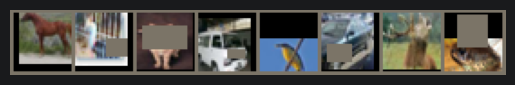

horse bird  cat   car   bird  car   deer  frog 


In [4]:
show_sample_batch(trainloader, CLASSES)

## Model Definition

### BasicBlock
The standard ResNet basic block: two 3×3 convolutions with BatchNorm
and a shortcut connection (identity or 1×1 projection).

### ResNet18
4 stages with 2 `BasicBlock`s each — [2, 2, 2, 2] — totaling ~11M parameters.

In [5]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

## Initialize Model & Print Summary

In [6]:
model = ResNet18().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affin

## Training Configuration

In [7]:
criterion = nn.CrossEntropyLoss()
epochs = 120
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,
    steps_per_epoch=len(trainloader),
    epochs=epochs,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4,
)

scaler = torch.amp.GradScaler('cuda')

checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path='../checkpoint/resnet18_latest.pth',
    best_model_path='../checkpoint/resnet18_best.pth',
    mode='max',
    verbose=True,
)

## Training Loop

In [8]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint,
)

[ModelCheckpoint] New best (max): 45.0300 — saved to ..\checkpoint\resnet18_best.pth
Epoch [ 1/120]  Train Loss: 1.9752  Val Loss: 1.5278  Val Acc: 45.03%  LR: 0.004183  Time: 16.35s
[ModelCheckpoint] New best (max): 53.7300 — saved to ..\checkpoint\resnet18_best.pth
Epoch [ 2/120]  Train Loss: 1.6121  Val Loss: 1.3052  Val Acc: 53.73%  LR: 0.004729  Time: 4.53s
[ModelCheckpoint] New best (max): 59.8100 — saved to ..\checkpoint\resnet18_best.pth
Epoch [ 3/120]  Train Loss: 1.4052  Val Loss: 1.1306  Val Acc: 59.81%  LR: 0.005636  Time: 4.50s
Epoch [ 4/120]  Train Loss: 1.2574  Val Loss: 1.2851  Val Acc: 58.83%  LR: 0.006896  Time: 4.39s
[ModelCheckpoint] New best (max): 67.9000 — saved to ..\checkpoint\resnet18_best.pth
Epoch [ 5/120]  Train Loss: 1.1338  Val Loss: 0.9554  Val Acc: 67.90%  LR: 0.008499  Time: 4.58s
[ModelCheckpoint] New best (max): 73.0800 — saved to ..\checkpoint\resnet18_best.pth
Epoch [ 6/120]  Train Loss: 1.0701  Val Loss: 0.7782  Val Acc: 73.08%  LR: 0.010433  Time

## Restore Best Weights & Test Evaluation

In [9]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CLASSES, device)
print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
for name, acc in per_class.items():
    print(f'  {name:5s}: {acc:.1f}%')

[ModelCheckpoint] Restored best weights from ..\checkpoint\resnet18_best.pth (score=95.7000)

Overall Test Accuracy: 95.22%

  plane: 95.4%
  car  : 98.5%
  bird : 94.1%
  cat  : 89.1%
  deer : 96.2%
  dog  : 90.7%
  frog : 97.5%
  horse: 97.1%
  ship : 97.4%
  truck: 96.2%


## Training Curves

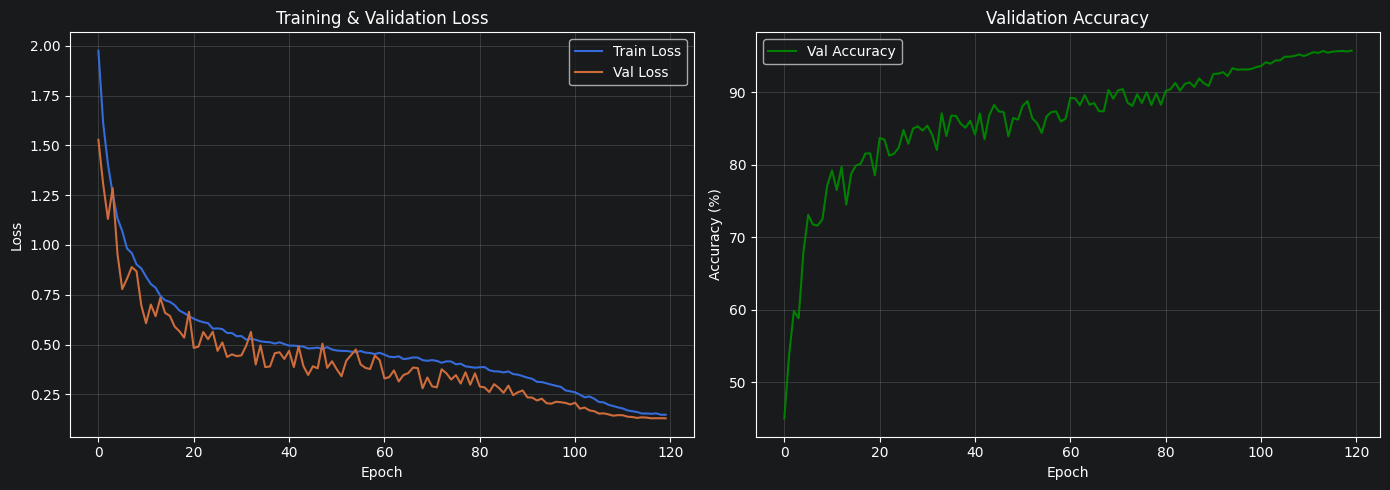

In [10]:
plot_training_curves(train_losses, val_losses, val_accuracies)